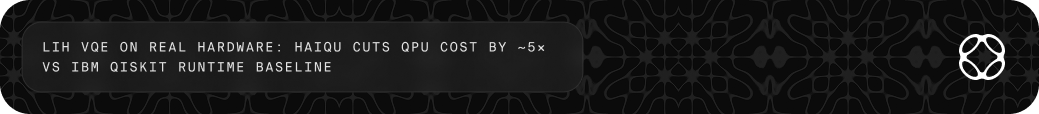

We run the Variational Quantum Eigensolver (VQE) for the **Lithium Hydride (LiH) molecule** on real IBM hardware (10 qubits), comparing **Haiqu + Pretrain**, **Haiqu** (random init), and **Baseline** (IBM Qiskit Runtime, NFT optimiser). At `MAXITER=10`, Haiqu's circuit packing and session management deliver **~5× faster QPU runtime** (550s → 115s) at **~5× lower cost** (~$880 → ~$184) compared to Baseline solution, running the same optimiser on the same backend. Classical pretraining further reduces energy error by **~2.7×** (341 mHa → 124 mHa) at no additional QPU cost.

### Encountered an issue? Let us know

Found a bug or have a question? [Submit feedback](https://feedback.haiqu.ai/)

## Initialize the notebook

Import the necessary libraries, set the run mode and credentials, and initialise the Haiqu SDK.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import EfficientSU2
from haiqu.sdk import haiqu
from haiqu.sdk.qml import VariationalProblem, NFTOptimizerOptions

# ── Configuration ───────────────────────────────────────────
RUN_ON_DEVICE = False           # set True to actually submit and retrieve
DEVICE_ID = "ibm_pittsburgh"    # or "fake_marrakesh" for a free local simulator
OPTIONS = {                     # set to {} when using a fake device
    "ibm_quantum_token":    "YOUR_IBM_QUANTUM_TOKEN",
    "ibm_quantum_instance": "YOUR_IBM_QUANTUM_INSTANCE",
}
SHOTS = 1000
MAXITER = 10
# Note: N_QUBITS is fixed by the LiH STO-3G + frozen-core mapping (10 qubits) — to
# change it, swap the molecule and regenerate lih_hamiltonian.json.

haiqu.login()
haiqu.init("LiH VQE")

'Set current experiment to: LiH VQE'

## The model

VQE prepares a parameterised trial state $|\psi(\boldsymbol{\theta})\rangle$ on a quantum computer and minimises

$$E(\boldsymbol{\theta}) = \langle \psi(\boldsymbol{\theta}) | H | \psi(\boldsymbol{\theta}) \rangle$$

classically over the parameters $\boldsymbol{\theta}$ until $E$ approaches the ground-state energy. We use the pre-computed LiH Hamiltonian (STO-3G basis, Jordan–Wigner mapping, frozen core), the `EfficientSU2` ansatz with 2 repetitions, and the NFT optimiser. Three runs are compared: warm-starting from classically pretrained parameters (Haiqu+Pretrain), random initialisation (Haiqu), and Baseline IBM Qiskit Runtime's Estimator on the same random initialisation. Classical Full Configuration Interaction (FCI) provides the exact reference; "chemical accuracy" is $1.6$ mHa.

In [2]:
import warnings
warnings.filterwarnings('ignore')

# Load pre-computed LiH Hamiltonian (STO-3G, Jordan-Wigner, frozen core)
with open("lih_hamiltonian.json") as f:
    data = json.load(f)

hamiltonian = SparsePauliOp.from_list([(t["label"], t["coeff"]) for t in data["pauli_terms"]])
num_qubits        = data["num_qubits"]
fci_energy        = data["fci_energy"]
energy_offset     = data["nuclear_repulsion_energy"] + data["frozen_core_energy"]

ansatz  = EfficientSU2(num_qubits=num_qubits, reps=2)
problem = VariationalProblem(ansatz, hamiltonian)

print(f"LiH: {len(hamiltonian)} Pauli terms on {num_qubits} qubits, FCI energy {fci_energy:.6f} Ha")
print(f"Ansatz: EfficientSU2(reps=2), {ansatz.num_parameters} parameters")

LiH: 276 Pauli terms on 10 qubits, FCI energy -7.882500 Ha
Ansatz: EfficientSU2(reps=2), 60 parameters


In [3]:
# Random initial parameters (used by both Haiqu-random and IBM for fair comparison)
rng = np.random.default_rng(42)
random_params = rng.uniform(-0.1 * np.pi, 0.1 * np.pi, problem.num_parameters).tolist()

# Classical pretraining (warm start) — only needed when running live
if RUN_ON_DEVICE:
    pretrained_params = haiqu.pretrain(problem, seed=5107, max_time=30).result()
    print(f"Pretrained {len(pretrained_params)} params (seed=5107, max_time=30s)")
else:
    pretrained_params = None
    print("Skipping pretrain — cached results were generated with seed=5107, max_time=30s")

Skipping pretrain — cached results were generated with seed=5107, max_time=30s


## Submit Haiqu VQE jobs

We submit two Haiqu VQE jobs (one with the pretrained warm start, one with random initial parameters), saving the job IDs to disk so we can retrieve results in a new session — VQE runs can take many minutes. Circuit packing (`pack_size=3`) and session management are enabled to reduce QPU cost. Set `RUN_ON_DEVICE = True` to execute on real hardware (requires IBM Quantum credentials); otherwise the notebook will load cached results from a previous run further down.

In [4]:
JOB_IDS_FILE = "saved_job_ids.json"

if RUN_ON_DEVICE:
    job_pretrain = haiqu.variational_optimization(
        problem, shots=SHOTS, device_id=DEVICE_ID, options=OPTIONS,
        initial_parameters=pretrained_params,
        optimizer_options=NFTOptimizerOptions(maxiter=MAXITER),
        use_session=True, use_packing=True, pack_size=3,
    )
    job_random = haiqu.variational_optimization(
        problem, shots=SHOTS, device_id=DEVICE_ID, options=OPTIONS,
        initial_parameters=random_params,
        optimizer_options=NFTOptimizerOptions(maxiter=MAXITER),
        use_session=True, use_packing=True, pack_size=3,
    )
    saved_job_ids = {"haiqu_pretrain": job_pretrain.id, "haiqu_random": job_random.id}
    with open(JOB_IDS_FILE, "w") as f:
        json.dump(saved_job_ids, f)
    print(f"Submitted: {saved_job_ids}")
    print(f"Job IDs saved to {JOB_IDS_FILE}")
else:
    print("Skipping live submission — cached results will be loaded next.")

Skipping live submission — cached results will be loaded next.


## Run IBM Qiskit Runtime Baseline

The IBM Qiskit Runtime Baseline runs **synchronously** in one call — unlike Haiqu's `variational_optimization`, which returns a job to retrieve later, `run_ibm_vqe` opens a Session, runs the full VQE loop, and returns the complete history when finished. We do this right after submitting the Haiqu jobs so all three runs are in flight together. `run_ibm_vqe` handles backend resolution internally: real IBM devices via `QiskitRuntimeService`, fake devices (e.g. `"fake_torino"`, `"fake_marrakesh"`) via `qiskit_ibm_runtime.fake_provider`.

In [5]:
if RUN_ON_DEVICE:
    from baseline_vqe import run_ibm_vqe
    ibm_results = run_ibm_vqe(
        ansatz=ansatz, hamiltonian=hamiltonian,
        device_id=DEVICE_ID, options=OPTIONS,
        shots=SHOTS, maxiter=MAXITER, initial_parameters=random_params,
    )
else:
    ibm_results = None
    print("Skipping IBM run — cached results will be loaded next.")

Skipping IBM run — cached results will be loaded next.


## Retrieve and consolidate results

For live runs, we load the saved job IDs and call `haiqu.get_job(job_id).result()` for both Haiqu jobs, then combine those with the IBM results from the previous cell into a single `results` dict. All three methods share the same field names — `loss_history`, `min_loss`, `qpu_cost`, `session_cost` — so the plots downstream don't need to special-case IBM.

In [6]:
RESULTS_FILE = "lih_vqe_hw_results.json"

if RUN_ON_DEVICE:
    with open(JOB_IDS_FILE) as f:
        saved_job_ids = json.load(f)
    job_pretrain = haiqu.get_job(saved_job_ids["haiqu_pretrain"])
    job_random   = haiqu.get_job(saved_job_ids["haiqu_random"])
    result_pretrain = job_pretrain.result()
    result_random   = job_random.result()

    results = {
        "haiqu_pretrain": {
            "loss_history": [float(e) for e in result_pretrain.loss_history],
            "min_loss":     float(result_pretrain.min_loss),
            "qpu_cost":     job_pretrain.qpu_cost,
            "session_cost": job_pretrain.session_cost,
        },
        "haiqu_random": {
            "loss_history": [float(e) for e in result_random.loss_history],
            "min_loss":     float(result_random.min_loss),
            "qpu_cost":     job_random.qpu_cost,
            "session_cost": job_random.session_cost,
        },
        "ibm": {
            "loss_history":     [float(e) for e in ibm_results["loss_history"]],
            "min_loss":         ibm_results["min_loss"],
            "qpu_cost":         ibm_results["qpu_cost"],
            "session_cost":     ibm_results["session_cost"],
            "job_time_metrics": ibm_results["job_time_metrics"],
        },
    }
    with open(RESULTS_FILE, "w") as f:
        json.dump(results, f, indent=2)
else:
    with open(RESULTS_FILE) as f:
        results = json.load(f)

> 💡 **Good to Know:** At `MAXITER=10`, Haiqu's circuit packing (`pack_size=3`) and session management cut QPU runtime from 550s to 115s (**~5× faster**) and QPU cost from ~$880 to ~$184 (**~5× cheaper**) compared to Baseline IBM Qiskit Runtime running the same NFT optimiser on the same backend. Classical pretraining (Haiqu + Pretrain) drops the final energy error from 341 mHa to 124 mHa — a **~2.7× improvement** at no additional QPU cost.

"Logged object to the experiment 'LiH VQE'. You can see logged data on Dashboard: https://dashboard.haiqu.ai"

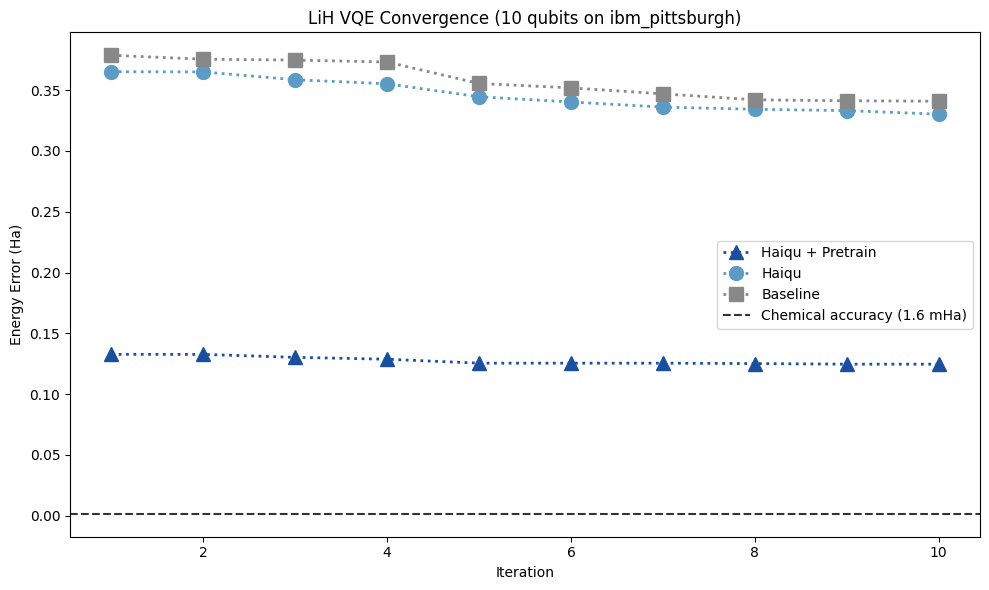

In [7]:
# Energy errors per iteration, |E - E_FCI|
pt_errors  = [abs(e + energy_offset - fci_energy) for e in results["haiqu_pretrain"]["loss_history"]]
rnd_errors = [abs(e + energy_offset - fci_energy) for e in results["haiqu_random"]["loss_history"]]
ibm_errors = [abs(e + energy_offset - fci_energy) for e in results["ibm"]["loss_history"]]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, len(pt_errors) + 1),  pt_errors,  marker="^", color="#1A4FA0",
        linestyle=":", linewidth=2, markersize=10, label="Haiqu + Pretrain")
ax.plot(range(1, len(rnd_errors) + 1), rnd_errors, marker="o", color="#5B9BC4",
        linestyle=":", linewidth=2, markersize=10, label="Haiqu")
ax.plot(range(1, len(ibm_errors) + 1), ibm_errors, marker="s", color="#888888",
        linestyle=":", linewidth=2, markersize=10, label="Baseline")
ax.axhline(y=0.0016, color="#333333", linewidth=1.5, linestyle="--", label="Chemical accuracy (1.6 mHa)")
ax.set(xlabel="Iteration", ylabel="Energy Error (Ha)",
       title=f"LiH VQE Convergence ({num_qubits} qubits on {DEVICE_ID})")
ax.legend()
plt.tight_layout()
haiqu.log(plt, name="convergence")

> 💡 **Good to Know:** NFT evaluates the cost function 3 times on iteration 1 (initial point + two shifts) and 2 times on each subsequent iteration (z₀ recycled), so total evaluations after $k$ iterations $= 2k + 1$. Haiqu costs at intermediate checkpoints are estimated proportionally as `total_cost × (2k + 1) / (2 × MAXITER + 1)`; for IBM, per-evaluation timing (`job_time_metrics`) is available, so cumulative QPU costs are computed exactly.

"Logged object to the experiment 'LiH VQE'. You can see logged data on Dashboard: https://dashboard.haiqu.ai"

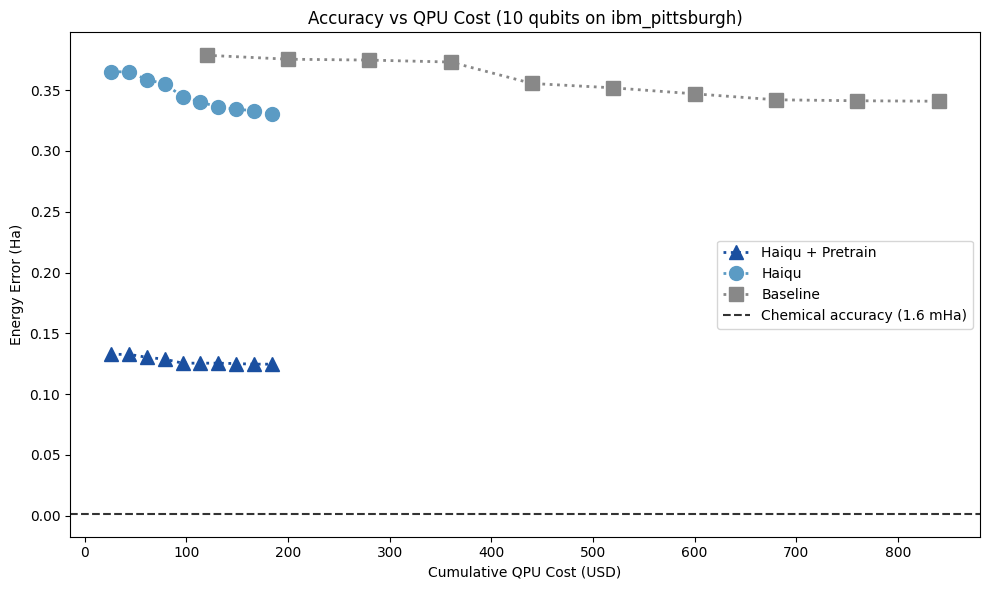

In [8]:
from baseline_vqe import IBM_USD_PER_SEC

# NFT evaluates the cost function 2k+1 times after k iterations (3 on iter 1, 2 each thereafter)
total_evals = 2 * MAXITER + 1
checkpoints = list(range(1, MAXITER + 1))

# Haiqu: estimate per-checkpoint QPU cost as a proportional fraction of the total
haiqu_total_pt  = (results["haiqu_pretrain"]["qpu_cost"] or {}).get("converted", {}).get("amount", 0.0)
haiqu_total_rnd = (results["haiqu_random"]["qpu_cost"]   or {}).get("converted", {}).get("amount", 0.0)
pt_costs  = [haiqu_total_pt  * (2 * k + 1) / total_evals for k in checkpoints]
rnd_costs = [haiqu_total_rnd * (2 * k + 1) / total_evals for k in checkpoints]

# IBM: cumulative QPU cost from per-evaluation timing × IBM_USD_PER_SEC
ibm_metrics = results["ibm"]["job_time_metrics"]
ibm_costs = [sum(m["qpu_time"] for m in ibm_metrics[:2 * k + 1]) * IBM_USD_PER_SEC for k in checkpoints]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(pt_costs,  pt_errors,  marker="^", color="#1A4FA0",
        linestyle=":", linewidth=2, markersize=10, label="Haiqu + Pretrain")
ax.plot(rnd_costs, rnd_errors, marker="o", color="#5B9BC4",
        linestyle=":", linewidth=2, markersize=10, label="Haiqu")
ax.plot(ibm_costs, ibm_errors, marker="s", color="#888888",
        linestyle=":", linewidth=2, markersize=10, label="Baseline")
ax.axhline(y=0.0016, color="#333333", linewidth=1.5, linestyle="--", label="Chemical accuracy (1.6 mHa)")
ax.set(xlabel="Cumulative QPU Cost (USD)", ylabel="Energy Error (Ha)",
       title=f"Accuracy vs QPU Cost ({num_qubits} qubits on {DEVICE_ID})")
ax.legend()
plt.tight_layout()
haiqu.log(plt, name="accuracy_vs_qpu_cost")

## Conclusion

This notebook compared three VQE workflows on a **10-qubit LiH benchmark** at `MAXITER=10`: **Haiqu + Pretrain**, **Haiqu** (random initial parameters), and **Baseline** (standard NFT optimiser). Same molecule, same ansatz, same optimiser, same backend — only the orchestration layer differs.

**Key findings:**

| Metric | Baseline | Haiqu | Haiqu + Pretrain | Improvement vs Baseline |
|---|---|---|---|---|
| QPU runtime | ~550 s | ~115 s | ~115 s | **~5× faster** |
| QPU cost | ~\$880 | ~\$184 | ~\$184 | **~5× cheaper** |
| Final energy error | 341 mHa | 330 mHa | **124 mHa** | **~2.7× lower** (with pretrain) |
| Iterations | 10 | 10 | 10 | — |

Two distinct advantages stack: Haiqu's **circuit packing** (`pack_size=3`) folds NFT's 2–3 evaluations per iteration into a single submission, and **session management** removes idle overhead — together they cut QPU cost by ~5× at fixed iteration budget. **Classical pretraining** then provides a warm start that reaches ~2.7× lower energy error at no additional QPU cost.

**Reproducibility:** Cached results are stored in `lih_vqe_hw_results.json` so the notebook runs end-to-end in cached-results mode without QPU access. To reproduce on hardware, fill in `OPTIONS` and set `RUN_ON_DEVICE = True`.

## Get in Touch

- **Documentation:** [docs.haiqu.ai](https://docs.haiqu.ai/)
- **Support & feedback:** [feedback.haiqu.ai](https://feedback.haiqu.ai/)
- **LinkedIn:** [Haiqu on LinkedIn](https://www.linkedin.com/company/haiquai/posts/?feedView=all)
- **Website:** [haiqu.ai](https://haiqu.ai/)
- **Business inquiries:** [info@haiqu.ai](mailto:info@haiqu.ai)

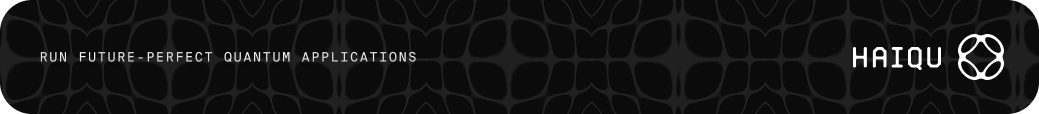